# Fisher Mean-Reversion Backtest Results
Runs the full backtest pipeline and renders performance metrics + charts.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

# Ensure repo root is on the path when running from notebooks/
ROOT = Path().resolve().parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.portfolio import Portfolio
from src.order_manager import OrderManager
from src.strategies.fisher_mean_reversion import FisherMeanReversion
from backtest import config
from backtest.execution_engine import BacktestExecutionEngine
from backtest.event_loop import run
from backtest.metrics import compute, summary_df

## Configuration

In [2]:
STARTING_CAPITAL = 10_000.0
RISK_PER_TRADE   = 0.01       # 1% per trade

# Strategy parameters — tweak these to explore
FISHER_PERIOD    = config.FISHER_PERIOD
FISHER_THRESHOLD = config.FISHER_THRESH
MA_PERIOD        = config.MA_PERIOD

## Load historical data

In [3]:
df = pd.read_parquet(config.HISTORY_PARQUET)
print(f"Loaded {len(df)} bars  |  {df.index.min().date()} → {df.index.max().date()}")
df.tail(3)

Loaded 7841 bars  |  2022-01-02 → 2026-04-30


,open,high,low,close,volume
timestamp,,,,,
2026-04-30 04:00:00+00:00,160.4250,160.725,159.7865,160.1370,-1.0
2026-04-30 08:00:00+00:00,160.1370,160.181,155.5550,156.3765,-1.0
2026-04-30 12:00:00+00:00,156.3765,157.112,156.2070,156.8150,-1.0


## Run backtest

In [4]:
strategy  = FisherMeanReversion(
    fisher_period=FISHER_PERIOD,
    fisher_threshold=FISHER_THRESHOLD,
    ma_period=MA_PERIOD,
)
portfolio = Portfolio(starting_capital=STARTING_CAPITAL)
order_mgr = OrderManager(risk_per_trade=RISK_PER_TRADE)
engine    = BacktestExecutionEngine(portfolio=portfolio)

portfolio = await run(df, strategy, order_mgr, engine, portfolio)
print(f"Trades completed: {len(portfolio.trade_history)}")

Trades completed: 840


## Performance summary

In [5]:
metrics = compute(portfolio)
summary_df(metrics)

,Value
Metric,
Total trades,840
Winning trades,335
Losing trades,505
Win rate,39.9%
Profit factor,1.02
Avg win,121.28
Avg loss,-79.04
Largest win,1554.35
Largest loss,-888.96


## Equity curve

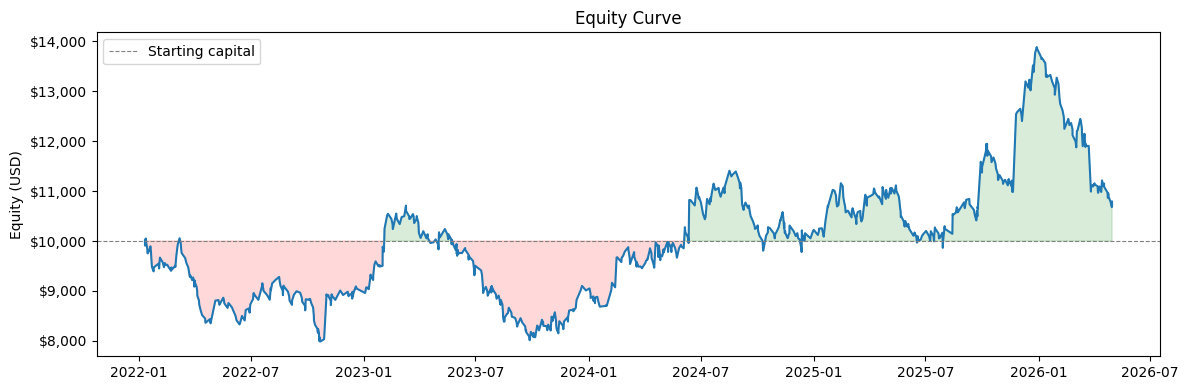

In [6]:
timestamps, equities = zip(*portfolio.equity_curve)
eq = pd.Series(list(equities), index=pd.DatetimeIndex(list(timestamps)))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(eq.index, eq.values, linewidth=1.5)
ax.axhline(STARTING_CAPITAL, color='grey', linestyle='--', linewidth=0.8, label='Starting capital')
ax.fill_between(eq.index, STARTING_CAPITAL, eq.values,
                where=(eq.values >= STARTING_CAPITAL), alpha=0.15, color='green')
ax.fill_between(eq.index, STARTING_CAPITAL, eq.values,
                where=(eq.values < STARTING_CAPITAL), alpha=0.15, color='red')
ax.set_title('Equity Curve')
ax.set_ylabel('Equity (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

## Drawdown

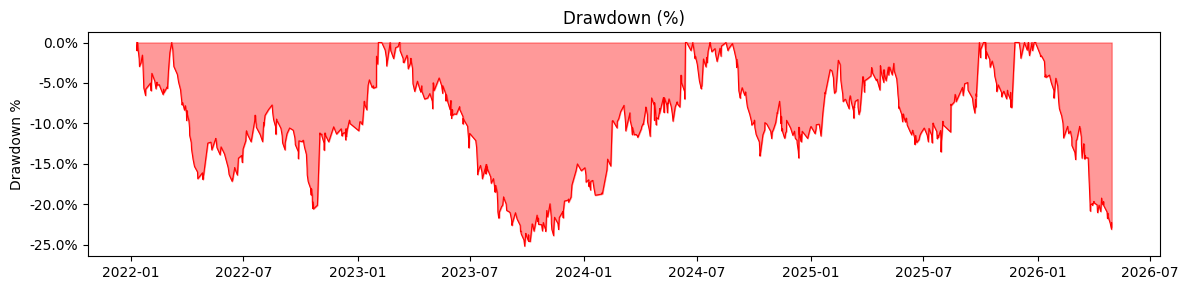

In [7]:
peak = eq.cummax()
drawdown = (eq - peak) / peak * 100

fig, ax = plt.subplots(figsize=(12, 3))
ax.fill_between(drawdown.index, drawdown.values, 0, alpha=0.4, color='red')
ax.plot(drawdown.index, drawdown.values, linewidth=0.8, color='red')
ax.set_title('Drawdown (%)')
ax.set_ylabel('Drawdown %')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
plt.tight_layout()
plt.show()

## P&L distribution

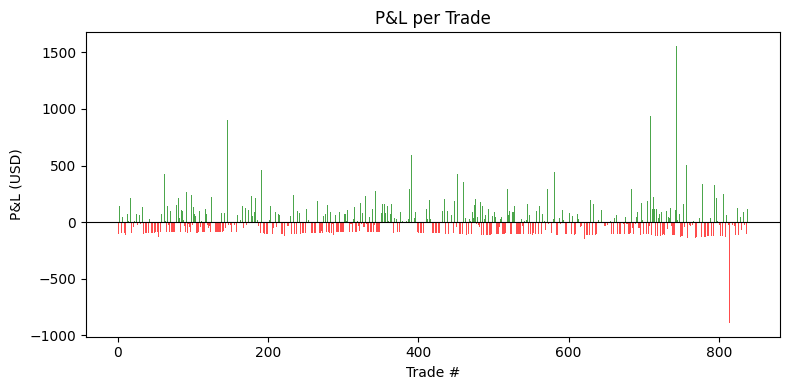

In [8]:
pnls = [t.pnl for t in portfolio.trade_history]

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['green' if p > 0 else 'red' for p in pnls]
ax.bar(range(len(pnls)), pnls, color=colors, alpha=0.7, width=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('P&L per Trade')
ax.set_xlabel('Trade #')
ax.set_ylabel('P&L (USD)')
plt.tight_layout()
plt.show()

## Exit reason breakdown

In [9]:
trade_df = portfolio.to_dataframe()
trade_df.groupby('exit_reason').agg(
    count=('pnl', 'count'),
    avg_pnl=('pnl', 'mean'),
    total_pnl=('pnl', 'sum'),
    win_rate=('pnl', lambda x: (x > 0).mean() * 100),
).round(2)

,count,avg_pnl,total_pnl,win_rate
exit_reason,,,,
stop,382,-87.09,-33270.28,7.85
take_profit,458,74.20,33984.48,66.59


## Full trade log

In [11]:
trade_df.sort_values('closed_at').style.map(
    lambda v: 'color: green' if isinstance(v, float) and v > 0 else
              'color: red'   if isinstance(v, float) and v < 0 else '',
    subset=['pnl']
)

,order_id,symbol,direction,quantity,filled_price,exit_price,exit_reason,pnl,closed_at
0,2240967f-a367-427f-a460-7538aed17daf,USDJPY,BUY,346.620451,115.801500,115.825700,take_profit,8.388215,2022-01-10 04:00:00+00:00
1,321301eb-051c-48e1-b2f0-cca2939721a6,USDJPY,BUY,353.029567,115.796500,115.513000,stop,-100.083882,2022-01-10 08:00:00+00:00
2,dc1a3b1d-0ca9-4f71-9161-6b5a30c45bae,USDJPY,BUY,401.145924,115.279500,115.635600,take_profit,142.848064,2022-01-11 12:00:00+00:00
3,cd70a9a8-894f-4141-a253-70e8e6b9133b,USDJPY,BUY,231.326868,115.467000,115.032500,stop,-100.511524,2022-01-12 12:00:00+00:00
4,5de30260-0b15-4b71-905e-42eb58e0442d,USDJPY,BUY,780.442421,114.118000,113.990500,stop,-99.506409,2022-01-14 00:00:00+00:00
5,4469b958-1223-457d-88cf-a3565565c968,USDJPY,BUY,380.352682,113.886500,113.627500,stop,-98.511345,2022-01-14 12:00:00+00:00
6,1ea287ce-00ec-49b0-97da-0fd819547783,USDJPY,BUY,145.561539,114.142000,114.467575,take_profit,47.391198,2022-01-17 00:00:00+00:00
7,27132862-a771-4739-8b29-69e77de8f714,USDJPY,SELL,258.575576,114.690000,114.323625,take_profit,94.735627,2022-01-19 04:00:00+00:00
8,cc80c873-b251-4d44-9028-46856cbdd501,USDJPY,BUY,655.281453,114.349000,114.198000,stop,-98.947499,2022-01-20 00:00:00+00:00
9,efc2aada-d81f-43d9-9d5f-5b7a877355d7,USDJPY,BUY,257.107676,114.396000,114.015000,stop,-97.958024,2022-01-20 12:00:00+00:00
